In [8]:
import pandas as pd   #importing important libries to prosses the data and build the model
import numpy as np
import sklearn as sk
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV,RandomizedSearchCV
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score,confusion_matrix
from sklearn.model_selection import train_test_split,cross_val_score


#Task 1: Exploratory Data Analysis (EDA)
1.	Load the Mushroom dataset and perform fundamental data exploration.
2.	Utilize histograms, box plots, or density plots to understand feature distributions.
3.	Investigate feature correlations to discern relationships within the data.


In [9]:
filename = '/content/mushroom.csv'#loading tne data
array  = dataframe.values
X=array[:,1:]
Y=array[:,0]


In [10]:
dataframe

,Unnamed: 0,cap_shape,cap_surface,cap_color,bruises,odor,gill_attachment,gill_spacing,gill_size,gill_color,...,veil_type,veil_color,ring_number,ring_type,spore_print_color,population,habitat,class,stalk_height,cap_diameter
0,1167,sunken,scaly,white,no,anise,descending,distant,broad,pink,...,partial,brown,two,sheathing,chocolate,clustered,waste,poisonous,14.276173,5.054983
1,1037,sunken,fibrous,red,no,anise,notched,crowded,narrow,chocolate,...,universal,brown,two,sheathing,brown,numerous,waste,edible,3.952715,19.068319
2,309,flat,grooves,purple,yes,foul,descending,crowded,broad,purple,...,universal,yellow,two,sheathing,purple,abundant,waste,poisonous,9.054265,7.205884
3,282,bell,scaly,pink,yes,fishy,notched,close,broad,orange,...,partial,yellow,two,cobwebby,green,clustered,grasses,poisonous,5.226499,20.932692
4,820,flat,smooth,yellow,yes,musty,free,crowded,narrow,orange,...,universal,white,none,none,yellow,clustered,urban,poisonous,14.037532,12.545245
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,863,sunken,scaly,brown,yes,foul,attached,crowded,narrow,chocolate,...,partial,orange,one,flaring,purple,abundant,leaves,poisonous,5.877891,17.464145
1996,1160,sunken,scaly,purple,yes,musty,attached,distant,narrow,red,...,partial,white,one,zone,yellow,numerous,waste,poisonous,6.500840,13.501957
1997,265,convex,grooves,green,yes,fishy,notched,close,narrow,pink,...,partial,brown,two,evanescent,yellow,abundant,woods,poisonous,13.558064,11.270020
1998,411,bell,smooth,white,no,pungent,free,close,narrow,orange,...,universal,yellow,one,cobwebby,brown,solitary,woods,poisonous,11.092703,8.423199


<Axes: ylabel='Count'>

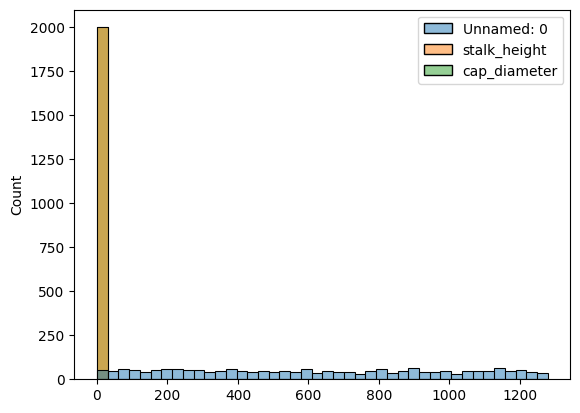

In [11]:
sns.histplot(dataframe) #plot to visualize the data

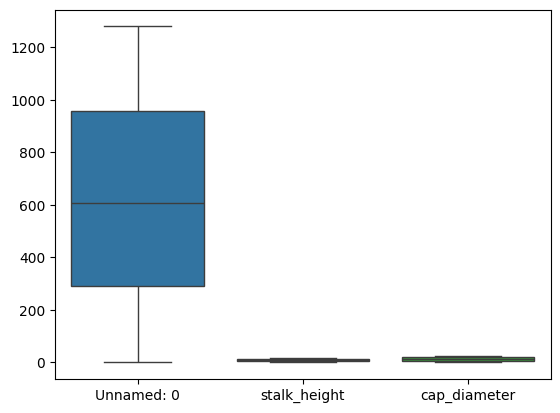

In [12]:
sns.boxplot(dataframe)
figuresize=(10,15)

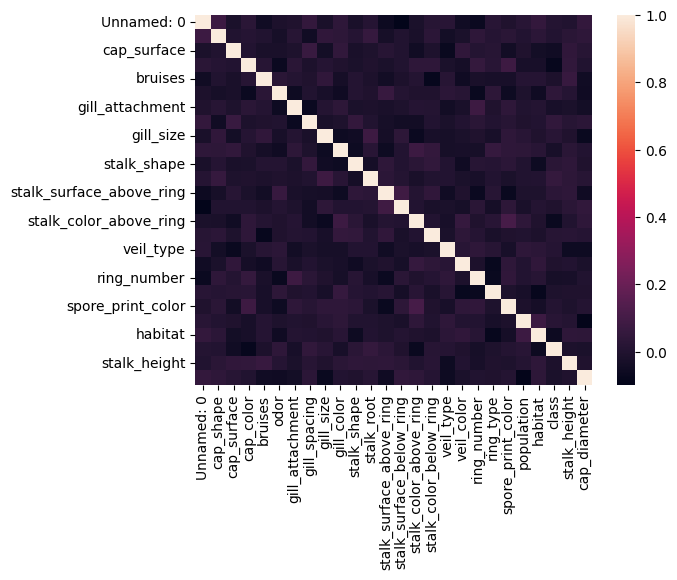

In [13]:
# Make a copy of the dataframe to avoid modifying the original if it's needed later
encoded_dataframe = dataframe.copy()

# Initialize LabelEncoder
le = LabelEncoder()

# Iterate through columns and apply LabelEncoder to object type columns
for column in encoded_dataframe.columns:
    if encoded_dataframe[column].dtype == 'object':
        encoded_dataframe[column] = le.fit_transform(encoded_dataframe[column])

# Calculate the correlation on the encoded dataframe
correlation_matrix = encoded_dataframe.corr()

# Plot the heatmap of the correlation matrix
hp = sns.heatmap(correlation_matrix)

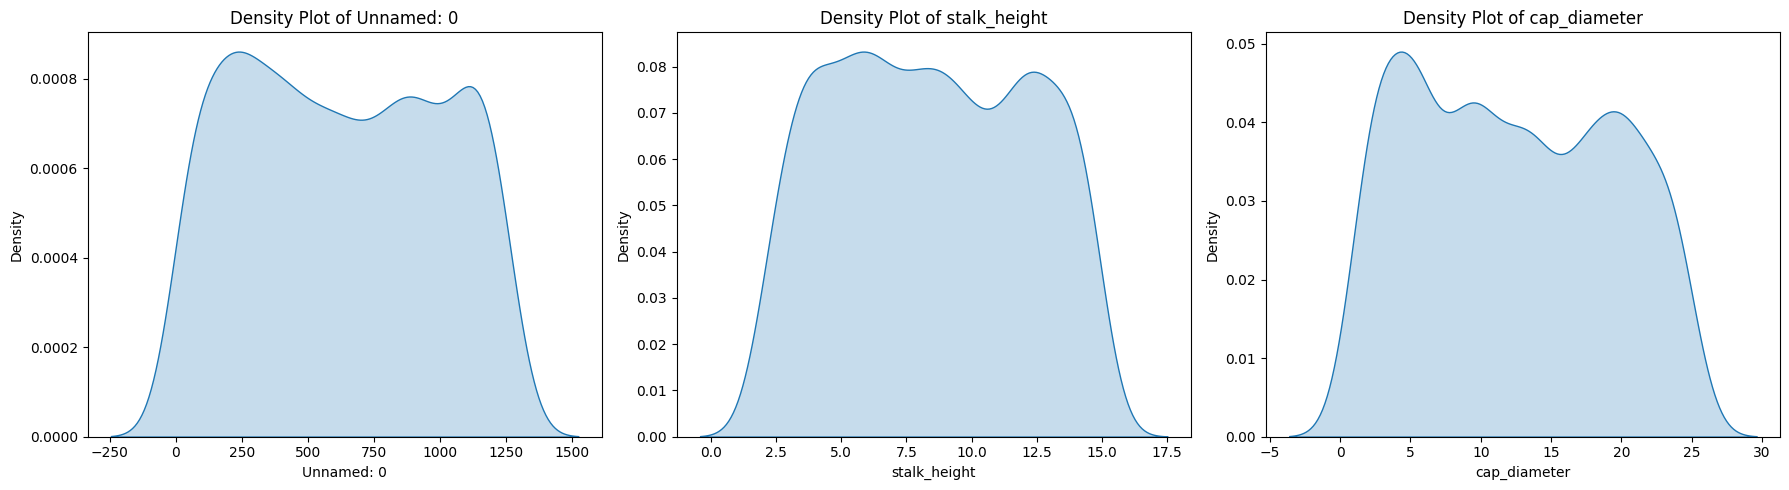

In [14]:
numerical_cols = dataframe.select_dtypes(include=np.number).columns #identifying numerical columns


if not numerical_cols.empty: # handle enpty numerical columns
    num_plots = len(numerical_cols)

    if num_plots <= 3:
        n_rows, n_cols = 1, num_plots
    elif num_plots <= 6:
        n_rows, n_cols = 2, (num_plots + 1) // 2
    else:
        n_rows, n_cols = (num_plots + 2) // 3, 3

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 6, n_rows * 5))
    axes = axes.flatten() #Determine subplot grid size

    for i, col in enumerate(numerical_cols): #generate density plot it loop through each numerical column
        sns.kdeplot(data=dataframe, x=col, fill=True, ax=axes[i])
        axes[i].set_title(f'Density Plot of {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Density')

    for j in range(num_plots, n_rows * n_cols):
        fig.delaxes(axes[j])#layout and display

    plt.tight_layout()
    plt.show()
else:
    print("No numerical columns found in the dataframe to plot density.")

#Task 2: Data Preprocessing
1.	Encode categorical variables if necessary.
2.	Split the dataset into training and testing sets.


In [15]:
X = encoded_dataframe.drop('class', axis=1)
Y = encoded_dataframe['class']

In [16]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=42) #spliting the data into traing and testing

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"Y_train shape: {Y_train.shape}")
print(f"Y_test shape: {Y_test.shape}")

X_train shape: (1400, 25)
X_test shape: (600, 25)
Y_train shape: (1400,)
Y_test shape: (600,)


#Task 3: Data Visualization
1.	Employ scatter plots, pair plots, or relevant visualizations to comprehend feature distributions and relationships.
2.	Visualize class distributions to gauge dataset balance or imbalance.


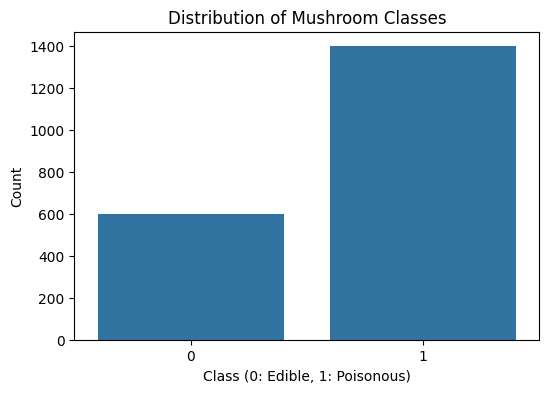

In [17]:
# Visualize class distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='class', data=encoded_dataframe)
plt.title('Distribution of Mushroom Classes')
plt.xlabel('Class (0: Edible, 1: Poisonous)')
plt.ylabel('Count')
plt.show()

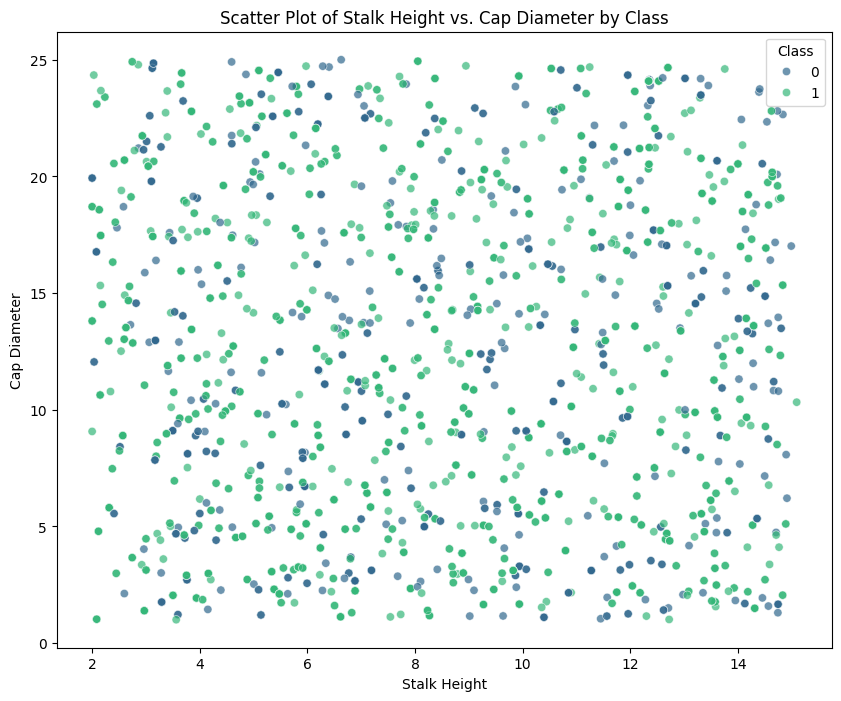

In [18]:
# Visualize relationship between stalk_height and cap_diameter, colored by class
plt.figure(figsize=(10, 8))
sns.scatterplot(x='stalk_height', y='cap_diameter', hue='class', data=encoded_dataframe, palette='viridis', alpha=0.7)
plt.title('Scatter Plot of Stalk Height vs. Cap Diameter by Class')
plt.xlabel('Stalk Height')
plt.ylabel('Cap Diameter')
plt.legend(title='Class')
plt.show()

#Task 4: SVM Implementation
1.	Implement a basic SVM classifier using Python libraries like scikit-learn.
2.	Train the SVM model on the training data.
3.	Evaluate model performance on the testing data using appropriate metrics (e.g., accuracy, precision, recall, F1-score).


In [19]:
clf = SVC(kernel = 'rbf',gamma=0.001)
clf.fit(X_train,Y_train)
y_pred = clf.predict(X_test)
acc=accuracy_score(Y_test,y_pred)
print(acc)
confusion_matrix(Y_test,y_pred)


0.705


array([[ 14, 171],
       [  6, 409]])

In [20]:
print(classification_report(Y_test, y_pred))

              precision    recall  f1-score   support

           0       0.70      0.08      0.14       185
           1       0.71      0.99      0.82       415

    accuracy                           0.70       600
   macro avg       0.70      0.53      0.48       600
weighted avg       0.70      0.70      0.61       600



#Task 5: Visualization of SVM Results
1.	Visualize classification results on the testing data.


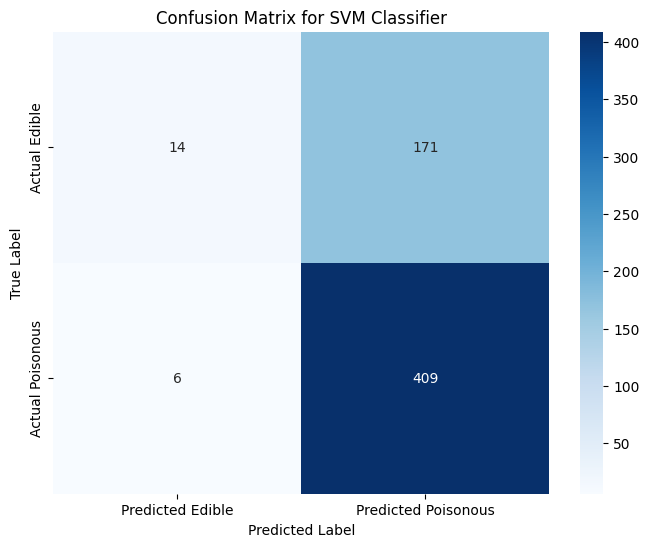

In [21]:
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm = confusion_matrix(Y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Edible', 'Predicted Poisonous'],
            yticklabels=['Actual Edible', 'Actual Poisonous'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for SVM Classifier')
plt.show()

#Task 6: Parameter Tuning and Optimization
1.	Experiment with different SVM hyperparameters (e.g., kernel type, regularization parameter) to optimize performance.


In [27]:
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [1, 0.1, 0.01, 0.001],
    'kernel': ['rbf', 'linear']
}

print("Parameter grid defined successfully:")
print(param_grid)

Parameter grid defined successfully:
{'C': [0.1, 1, 10, 100], 'gamma': [1, 0.1, 0.01, 0.001], 'kernel': ['rbf', 'linear']}


In [28]:
clf = SVC()
param_grid = [
    {'kernel': ['rbf'], 'gamma': [1, 0.1, 0.01, 0.001], 'C': [0.1, 1, 10, 100]}
]
gsv = GridSearchCV(clf, param_grid, cv=5)
gsv.fit(X_train, Y_train)



GridSearchCV(cv=5, estimator=SVC(),
             param_grid=[{'C': [0.1, 1, 10, 100],
                          'gamma': [1, 0.1, 0.01, 0.001], 'kernel': ['rbf']}])

In [31]:
gsv.best_params_ ,gsv.best_score_

({'C': 1, 'gamma': 1, 'kernel': 'rbf'}, np.float64(0.837857142857143))

In [32]:
clf = SVC(C=10,gamma=0.001,kernel='rbf')
clf.fit(X_train,Y_train)
y_pred = clf.predict(X_test)
acc= accuracy_score(Y_test,y_pred)*100
print("Accuracy=",acc)
confusion_matrix(Y_test,y_pred)

Accuracy= 82.5


array([[119,  66],
       [ 39, 376]])

#Task 7: Comparison and Analysis
1.	Compare SVM performance with various kernels (e.g., linear, polynomial, radial basis function).
2.	Analyze SVM strengths and weaknesses for the Mushroom dataset based on EDA and visualization results.
3.	Discuss practical implications of SVM in real-world classification tasks.


Kernel     | Accuracy  
-------------------------
linear     | 69.17%
poly       | 69.17%
rbf        | 69.17%
sigmoid    | 59.50%


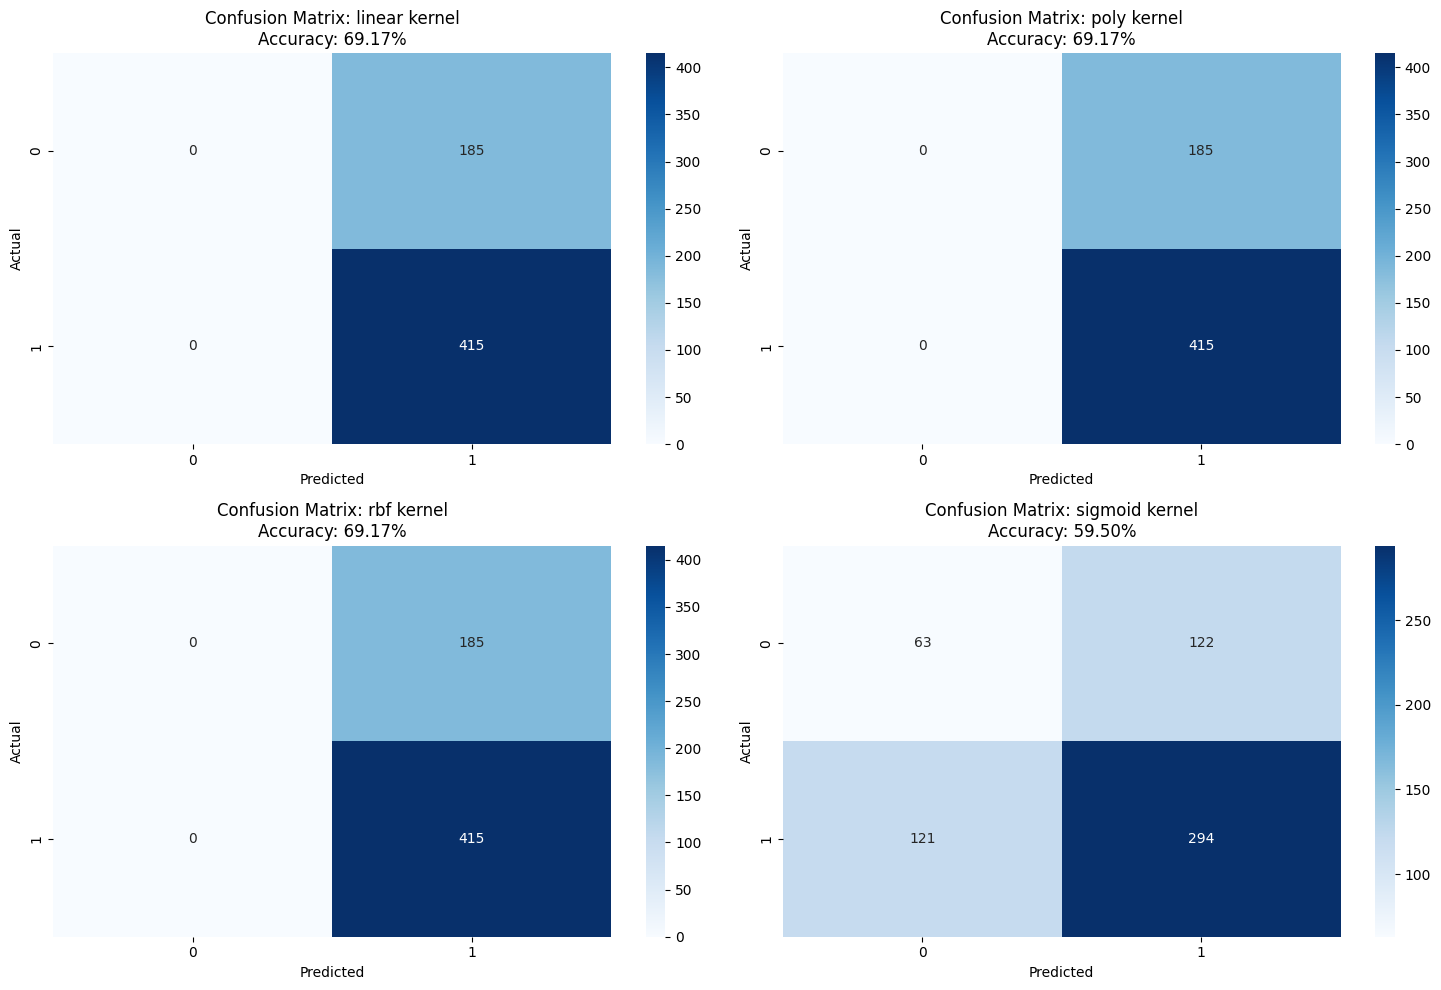

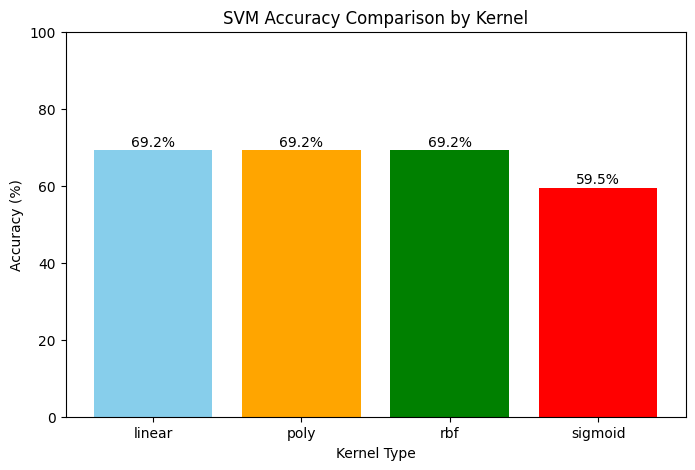

In [36]:
# --- SECTION 1: Compare SVM Performance with Various Kernels ---

# Define the kernels to compare
kernels = ['linear', 'poly', 'rbf', 'sigmoid']
results = {}

print(f"{'Kernel':<10} | {'Accuracy':<10}")
print("-" * 25)

plt.figure(figsize=(15, 10))

for i, kernel in enumerate(kernels):
    # Initialize SVM with the specific kernel
    # Note: You can adjust C and gamma here if needed, keeping defaults for comparison
    clf = SVC(kernel=kernel, C=1.0, random_state=42)

    # Train the model
    clf.fit(X_train, Y_train)

    # Predict
    y_pred = clf.predict(X_test)

    # Calculate accuracy
    acc = accuracy_score(Y_test, y_pred) * 100
    results[kernel] = acc

    print(f"{kernel:<10} | {acc:.2f}%")

    # Plot Confusion Matrix for each kernel
    plt.subplot(2, 2, i+1)
    cm = confusion_matrix(Y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix: {kernel} kernel\nAccuracy: {acc:.2f}%')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')

plt.tight_layout()
plt.show()

# --- SECTION 2: Visualization of Comparison ---

# Bar chart to compare accuracies
plt.figure(figsize=(8, 5))
plt.bar(results.keys(), results.values(), color=['skyblue', 'orange', 'green', 'red'])
plt.title('SVM Accuracy Comparison by Kernel')
plt.xlabel('Kernel Type')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 100)
for i, v in enumerate(results.values()):
    plt.text(i, v + 1, f"{v:.1f}%", ha='center')
plt.show()


# Practical Implications of SVMs in Real-World Classification Tasks

Support Vector Machines (SVMs) are powerful and versatile machine learning models used for classification, regression, and outlier detection. Here's a discussion of their practical implications, including strengths, weaknesses, and specific considerations for mushroom identification.

# Strengths of SVMs:

1.  **Effectiveness in High-Dimensional Spaces**: SVMs perform particularly well in datasets with a large number of features, even when the number of features is greater than the number of samples. This is because their decision boundary relies only on a subset of the training data (support vectors).
2.  **Clear Margin of Separation**: SVMs aim to find a hyperplane that maximizes the margin between the different classes. This clear separation can lead to better generalization performance, especially when classes are linearly separable or can be made so in a higher dimension using kernel tricks.
3.  **Versatility with Kernel Functions**: The use of various kernel functions (e.g., linear, polynomial, RBF, sigmoid) allows SVMs to handle non-linear decision boundaries, extending their applicability to a wide range of complex datasets.
4.  **Robustness to Overfitting (with proper regularization)**: The maximal margin principle naturally provides a form of regularization, making SVMs less prone to overfitting, especially when a good C parameter is chosen.

# Weaknesses of SVMs:

1.  **Sensitivity to Hyperparameter Tuning**: The performance of SVMs is highly dependent on the choice of hyperparameters (e.g., C, gamma for RBF kernel). Improper tuning can lead to poor performance, and finding optimal parameters can be computationally intensive, often requiring techniques like GridSearchCV or RandomizedSearchCV.
2.  **Computational Cost for Large Datasets**: For very large datasets, training an SVM can be computationally expensive and time-consuming, particularly for non-linear kernels. The complexity typically scales between O(n^2) and O(n^3), where n is the number of samples.
3.  **Less Intuitive Interpretability**: Unlike models such as decision trees or linear regression, understanding the exact decision-making process of an SVM, especially with non-linear kernels, can be less straightforward. It's often harder to explain why a particular prediction was made.
4.  **Performance with Overlapping Classes**: When classes are highly overlapping, SVMs might not perform as well as other models, as finding a clear margin becomes difficult, potentially leading to a higher number of support vectors and less distinct boundaries.

# Application to Mushroom Identification and Importance of Avoiding False Negatives:

In the context of mushroom identification, SVMs can be a valuable tool for classifying mushrooms as edible or poisonous. However, the stakes are exceptionally high, making the avoidance of **false negatives** critically important.

*   **False Negative (Type II Error)**: This occurs when a poisonous mushroom is incorrectly classified as edible. The practical implication of such an error in mushroom identification is severe and potentially fatal. Consuming a poisonous mushroom due to a false negative prediction can lead to serious illness, organ damage, or even death.

Therefore, when deploying an SVM (or any classification model) for mushroom identification, the model's evaluation metrics must prioritize minimizing false negatives above all else. This might involve:

*   **Adjusting Decision Thresholds**: If possible, adjusting the decision threshold to be more conservative, even if it increases false positives (classifying an edible mushroom as poisonous).
*   **Optimizing for Recall (of the 'poisonous' class)**: Focusing on metrics like recall for the poisonous class is crucial, as it measures the proportion of actual poisonous mushrooms that were correctly identified. A high recall for the poisonous class means fewer false negatives.
*   **Cost-Sensitive Learning**: Implementing cost-sensitive learning techniques where the misclassification of a poisonous mushroom as edible incurs a much higher penalty than the reverse.

While SVMs can provide accurate classifications, their deployment in such life-critical applications necessitates a careful understanding of their error types and a strong emphasis on mitigating the most dangerous outcomes, specifically false negatives. In such scenarios, a cautious approach that might lead to rejecting some edible mushrooms (false positives) is far more acceptable than risking human life with a false negative.
